In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

Function 8: High-dimensional Optimisation

You’ve reach the final, 8-dimensional search space. High-dimensional black-box optimisation can be very difficult, so sticking to local solutions is not the worst idea here.


In [31]:
import ast
import numpy as np

def queries_for_function(number):
    if number < 1 or number > 8:
        return []
        
    with open('../queries.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        file_content = file.read()
        
    all_queries = file_content.split('])]')
    
    formatted_queries = [query.replace('\n', '') + '])]' for query in all_queries if query]
    
    actual_queries = []
    for query in formatted_queries:
        formatted_query = query.replace('array(', '').replace(')', '').strip()
        
        try:
            query_formatted_as_list = ast.literal_eval(formatted_query)  # Use ast.literal_eval for safety
            query_as_2d_array = np.array(query_formatted_as_list, dtype=object)
            actual_queries.append(query_as_2d_array[number - 1])
        except (SyntaxError, IndexError, ValueError) as e:
            print(f"Warning: Skipping query due to error - {e}")
            continue

    return actual_queries


def observations_for_function(number):
    if number < 1 or number > 8:
        return []
    
    data = []
    
    with open('../observations.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        for line in file:
            try:
                # Extract the float values from the line
                values = [float(value.split('(')[1].split(')')[0]) for value in line.strip().split(', ')]
                data.append(values)
            except (IndexError, ValueError) as e:
                print(f"Warning: Skipping line due to error - {e}")
                continue
            
    # Convert the list of lists into a numpy array
    data_array = np.array(data)
    
    # Extract each column as a numpy array
    columns = [data_array[:, i] for i in range(data_array.shape[1])] if data_array.size > 0 else []
    
    return columns[number - 1] if number - 1 < len(columns) else []

In [32]:
X = np.load("initial_inputs.npy")
X, len(X)

(array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
         0.57533801, 0.31031095, 0.73428138],
        [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
         0.70790879, 0.63538449, 0.10713163],
        [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
         0.09165169, 0.59241515, 0.36732026],
        [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.0937283 ,
         0.19742533, 0.7558269 , 0.29247234],
        [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
         0.28920692, 0.55729515, 0.59388173],
        [0.77881834, 0.0034195 , 0.33798313, 0.51952778, 0.82090699,
         0.53724669, 0.5513471 , 0.66003209],
        [0.90864932, 0.0622497 , 0.23825955, 0.76660355, 0.13233596,
         0.99024381, 0.68806782, 0.74249594],
        [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
         0.74899176, 0.23090707, 0.09791562],
        [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
         0.

In [33]:
queries = queries_for_function(8)
X = np.vstack([X, queries])
X, len(X)

(array([[6.04994453e-01, 2.92215020e-01, 9.08452748e-01, 3.55506242e-01,
         2.01668719e-01, 5.75338005e-01, 3.10310951e-01, 7.34281377e-01],
        [1.78006959e-01, 5.66222654e-01, 9.94861845e-01, 2.10325006e-01,
         3.20152657e-01, 7.07908792e-01, 6.35384489e-01, 1.07131627e-01],
        [9.07697668e-03, 8.11626153e-01, 5.20520360e-01, 7.56866752e-02,
         2.65111825e-01, 9.16516894e-02, 5.92415145e-01, 3.67320262e-01],
        [5.06028164e-01, 6.53730123e-01, 3.63410779e-01, 1.77981049e-01,
         9.37283044e-02, 1.97425331e-01, 7.55826900e-01, 2.92472339e-01],
        [3.59909264e-01, 2.49075679e-01, 4.95997170e-01, 7.09214981e-01,
         1.14987195e-01, 2.89206921e-01, 5.57295151e-01, 5.93881726e-01],
        [7.78818344e-01, 3.41949948e-03, 3.37983130e-01, 5.19527778e-01,
         8.20906993e-01, 5.37246689e-01, 5.51347098e-01, 6.60032086e-01],
        [9.08649322e-01, 6.22496998e-02, 2.38259546e-01, 7.66603545e-01,
         1.32335962e-01, 9.90243814e-01, 6.88

In [34]:
y = np.load("initial_outputs.npy")
y, len(y)

(array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
        8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
        7.85454099, 6.79198578, 8.97655402, 7.3790829 , 9.598482  ,
        8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
        7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
        8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
        7.92375877, 8.42175924, 8.2780624 , 7.11345716, 6.40258841,
        8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525]),
 40)

In [35]:
observations = observations_for_function(8)
for observation in observations:
    y = np.append(y, [observation], axis=0)
y, len(y)

(array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
        8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
        7.85454099, 6.79198578, 8.97655402, 7.3790829 , 9.598482  ,
        8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
        7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
        8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
        7.92375877, 8.42175924, 8.2780624 , 7.11345716, 6.40258841,
        8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
        8.79430126, 9.3063    , 8.5383    , 9.47029948, 8.97030188,
        8.67530713, 9.16893263, 5.88585105, 7.3564238 , 6.66223597,
        9.2022995 , 9.2022995 , 9.46629962]),
 53)

In [36]:
def best_observation(y):
    best_idx = np.argmin(np.abs(y))  # Find the index where y is closest to zero
    best_observation_so_far = y[best_idx]
    best_query_so_far = X[best_idx]
    print("Best observation so far (closest to zero):", best_observation_so_far)
    print("Best query so far:", best_query_so_far)
    return best_observation_so_far, best_query_so_far

best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 5.5921933895401965
Best query so far: [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
 0.49082694 0.31368272]


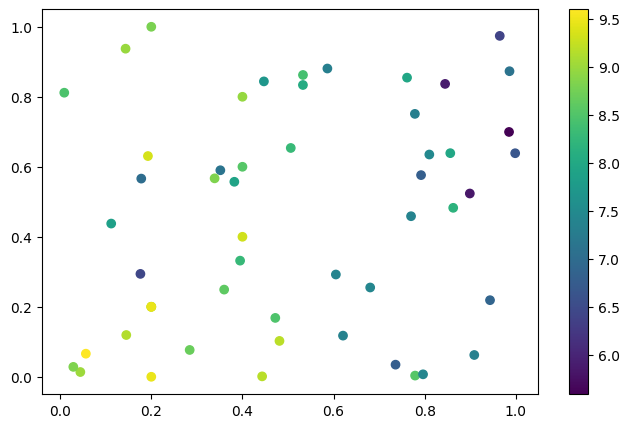

In [37]:
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.colorbar()

Text(0.5, 0.92, 'Scatter Plot of Contamination Sources Input Data Points with Output Variable y')

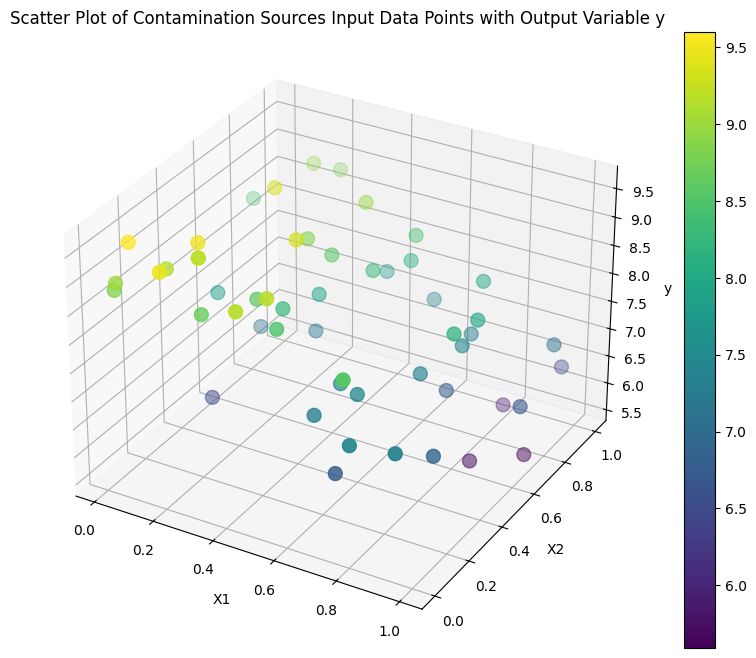

In [38]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X[:,0], X[:,1], y, c=y, cmap='viridis', s=100)

plt.colorbar(sc)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')

ax.set_title('Scatter Plot of Contamination Sources Input Data Points with Output Variable y')


**Acquisition Functions**

In [39]:
#UCB is useful when you want a balance between exploring new areas of the search space (high uncertainty) and exploiting known areas 
#with high mean values. The parameter β controls this balance. It's a good general-purpose acquisition function for many optimization problems.
def upper_confidence_bound(post_mean, post_std, beta):
    ucb = post_mean + beta * post_std # upper confidence bpon (ucb) = mu + kappa * sigma 
    print("\n\nUCB Shape: ", np.shape(ucb))
    return ucb


#PI is more focused on exploitation, as it prioritizes areas where the predicted mean is higher than the current best observed value (ymax)
#Use PI when you have a well-calibrated model and you want to focus on improving the best observed value.
def probability_of_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI Shape: ", np.shape(PI))
    return PI


def probability_of_improvement_with_exploration_term(post_mean, post_std, y_max, epsilon):
    # Calculate the improvement with exploration term
    improvement = post_mean - (y_max + epsilon)
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI With Exploitation Term Shape: ", np.shape(PI))
    return PI


#EI provides a balance between exploration and exploitation, similar to UCB, but it also considers the magnitude of improvement.
#Use EI when you want to maximize the expected improvement over the current best observed value.
def expected_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the expected improvement
    EI = improvement * norm.cdf(Z) + post_std * norm.pdf(Z)
    print("\n\nEI Shape: ", np.shape(EI))
    return EI

#Thompson Sampling is useful when you want to sample from the posterior distribution of the model, which inherently balances exploration and exploitation.
#Use Thompson Sampling when you want a stochastic approach to selecting the next point.
def thompson_sampling(post_mean, post_std):
    # Sample from the posterior distribution
    samples = np.random.normal(post_mean, post_std)
    print("\n\nThompson Samples Shape: ", np.shape(samples))
    return samples

**Input Sampling Methods**

In [40]:
def exploration_grid():
    x1_grid = np.linspace(0.000001, 0.999999, 6)
    x2_grid = np.linspace(0.000001, 0.999999, 6)
    x3_grid = np.linspace(0.000001, 0.999999, 6)
    x4_grid = np.linspace(0.000001, 0.999999, 6)
    x5_grid = np.linspace(0.000001, 0.999999, 6)
    x6_grid = np.linspace(0.000001, 0.999999, 6)
    x7_grid = np.linspace(0.000001, 0.999999, 6)
    x8_grid = np.linspace(0.000001, 0.999999, 6)

    x1_grid, x2_grid, x3_grid, x4_grid, x5_grid, x6_grid, x7_grid, x8_grid = np.meshgrid(x1_grid, x2_grid, x3_grid, x4_grid, x5_grid, x6_grid, x7_grid, x8_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel(),  x4_grid.ravel(),  x5_grid.ravel(),  x6_grid.ravel(),  x7_grid.ravel(),  x8_grid.ravel()]).T

    return x_grid

def exploitation_grid(center, delta=0.05):
    """
    Create a grid for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    x1, x2, x3, x4, x5, x6, x7, x8 = center
    x1_grid = np.linspace(max(0.000001, x1 - delta), min(0.999999, x1 + delta), 6)
    x2_grid = np.linspace(max(0.000001, x2 - delta), min(0.999999, x2 + delta), 6)
    x3_grid = np.linspace(max(0.000001, x3 - delta), min(0.999999, x3 + delta), 6)
    x4_grid = np.linspace(max(0.000001, x4 - delta), min(0.999999, x4 + delta), 6)
    x5_grid = np.linspace(max(0.000001, x5 - delta), min(0.999999, x5 + delta), 6)
    x6_grid = np.linspace(max(0.000001, x6 - delta), min(0.999999, x6 + delta), 6)
    x7_grid = np.linspace(max(0.000001, x7 - delta), min(0.999999, x7 + delta), 6)
    x8_grid = np.linspace(max(0.000001, x8 - delta), min(0.999999, x8 + delta), 6)

    x1_grid, x2_grid, x3_grid, x4_grid, x5_grid, x6_grid, x7_grid, x8_grid = np.meshgrid(x1_grid, x2_grid, x3_grid, x4_grid, x5_grid, x6_grid, x7_grid, x8_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel(), x4_grid.ravel(), x5_grid.ravel(),  x6_grid.ravel(),  x7_grid.ravel(),  x8_grid.ravel()]).T

    return x_grid

def exploration_latin_hypercube():
    """
    Create a Latin Hypercube sample for exploration.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (0.000001, 0.999999),  # x1
        (0.000001, 0.999999),  # x2
        (0.000001, 0.999999),  # x3
        (0.000001, 0.999999),  # x4
        (0.000001, 0.999999),  # x5
        (0.000001, 0.999999),  # x6
        (0.000001, 0.999999),  # x7
        (0.000001, 0.999999)   # x8
    ]
    sampler = qmc.LatinHypercube(d=8)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

def exploitation_latin_hypercube(center, delta=0.05):
    """
    Create a Latin Hypercube sample for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (max(0.000001, center[0] - delta), min(0.999999, center[0] + delta)),  # x1
        (max(0.000001, center[1] - delta), min(0.999999, center[1] + delta)),  # x2
        (max(0.000001, center[2] - delta), min(0.999999, center[2] + delta)),  # x3
        (max(0.000001, center[3] - delta), min(0.999999, center[3] + delta)),  # x4
        (max(0.000001, center[4] - delta), min(0.999999, center[4] + delta)),  # x5
        (max(0.000001, center[5] - delta), min(0.999999, center[5] + delta)),  # x6
        (max(0.000001, center[6] - delta), min(0.999999, center[6] + delta)),  # x7
        (max(0.000001, center[7] - delta), min(0.999999, center[7] + delta))   # x8
    ]
    sampler = qmc.LatinHypercube(d=8)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

In [41]:
def query_black_box_function_with_default_kernel(X, y, x_grid, acquisition_func):
    
    beta = 1.96
    model = GaussianProcessRegressor()
    model.fit(X, y)
       
    post_mean, post_std = model.predict(x_grid, return_std=True) #post_mean is y_pred and post_std is sigma i.e. s
    #acquisition_function = post_mean + beta * post_std # upper confidence bound (ucb) = mu + kappa * sigma mu + kappa * sigma 
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
        
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)  # Define y_max as the maximum observed value
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
        
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)

    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)

    else: #thompson_sampling
         acquisition_function = acquisition_func(post_mean, post_std)
    
    next_query = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]
    
    next_query = next_query.reshape(1,8)
    y_pred = np.array([y_pred])
    
    print(f"Query to Black Box Function Maximizes at Input: ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f}-{next_query[0][5]:.6f}-{next_query[0][6]:.6f}-{next_query[0][7]:.6f})")
    print(f"Predicted Value at ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f}-{next_query[0][5]:.6f}-{next_query[0][6]:.6f}-{next_query[0][7]:.6f}) is {y_pred[0]})") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
   
    return next_query, y_pred

In [42]:
def next_query_with_default_kernel(X, y, x_grid):
    x_random = np.random.uniform(size = 2)
    print(f"Random Query: {x_random[0]:.6f}-{x_random[1]:.6f}")

    x_ucb, y_pred_ucb = query_black_box_function_with_default_kernel(X, y, x_grid, upper_confidence_bound)
    
    x_pi, y_pred_pi = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement)
    
    x_piet, y_pred_piet = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement_with_exploration_term)
    
    x_ei, y_pred_ei = query_black_box_function_with_default_kernel(X, y, x_grid, expected_improvement)
    
    x_ts, y_pred_ts = query_black_box_function_with_default_kernel(X, y, x_grid, thompson_sampling)

    return x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts

**Exploration**

Explore the whole space with **defalut** RBF Kernel

In [43]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploration_grid())

Random Query: 0.884681-0.578068


UCB Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.200001-0.000001-0.799999-0.600000-0.200001-0.600000)
Predicted Value at (0.200001-0.200001-0.200001-0.000001-0.799999-0.600000-0.200001-0.600000) is 9.889608192813084)
Index of maximum acquisition function value:  335349


PI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.200001-0.200001-0.600000-0.600000-0.400000-0.600000)
Predicted Value at (0.200001-0.200001-0.200001-0.200001-0.600000-0.600000-0.400000-0.600000) is 9.935308896458688)
Index of maximum acquisition function value:  336435


PI With Exploitation Term Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.200001-0.000001-0.799999-0.600000-0.200001-0.600000)
Predicted Value at (0.200001-0.200001-0.200001-0.000001-0.799999-0.600000-0.200001-0.600000) is 9.889608192813084)
Index of maximum acquisition function value:  335349




**Exploitation**

In [44]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 5.5921933895401965
Best query so far: [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
 0.49082694 0.31368272]


In [45]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploitation_grid(best_query_so_far))

Random Query: 0.705022-0.177132


UCB Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.934933-0.649506-0.948885-0.130148-0.630143-0.281087-0.440827-0.363683)
Predicted Value at (0.934933-0.649506-0.948885-0.130148-0.630143-0.281087-0.440827-0.363683) is 6.102915686443206)
Index of maximum acquisition function value:  1265


PI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.934933-0.649506-0.948885-0.130148-0.530143-0.181087-0.440827-0.263683)
Predicted Value at (0.934933-0.649506-0.948885-0.130148-0.530143-0.181087-0.440827-0.263683) is 6.05303687342088)
Index of maximum acquisition function value:  0


PI With Exploitation Term Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.934933-0.649506-0.948885-0.130148-0.530143-0.181087-0.440827-0.263683)
Predicted Value at (0.934933-0.649506-0.948885-0.130148-0.530143-0.181087-0.440827-0.263683) is 6.05303687342088)
Index of maximum acquisition function value:  0


EI Shape:  (16

**Hyperparameter Tuning using gp_minimize**

In [46]:
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic, DotProduct
def query_black_box_function_with_hyper_parameters(X, y, x_grid, acquisition_func, kernel_type, rbf_lengthscale, noise_assumption, restarts, beta):
    # Define the kernel based on the kernel_type parameter
    if kernel_type == 'RBF':
        kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2)) * C(1.0, (1e-10, 1e10))

    elif kernel_type == 'Matern':
        kernel = Matern(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2), nu=1.5)

    elif kernel_type == 'RationalQuadratic':
        kernel = RationalQuadratic(length_scale=rbf_lengthscale, alpha=1.0) * C(1.0, (1e-10, 1e10))
      
    elif kernel_type == 'DotProduct':
        kernel = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3)) + C(1.0, (1e-10, 1e10))
    else:
        kernel = None

    # Create and fit the Gaussian Process model
    if kernel is None:
        model = GaussianProcessRegressor()
    else:   
        model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption, n_restarts_optimizer=restarts)

    model.fit(X, y)

    # Predict the mean and standard deviation
    post_mean, post_std = model.predict(x_grid, return_std=True)

    # Compute the acquisition function
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)
    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    else:  # thompson_sampling
        acquisition_function = acquisition_func(post_mean, post_std)

    # Find the point that maximizes the acquisition function
    next_query = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]

    next_query = next_query.reshape(1, 8)
    y_pred = np.array([y_pred])

    print(f"Query to Black Box Function Maximizes at Input: ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f}-{next_query[0][5]:.6f}-{next_query[0][6]:.6f}-{next_query[0][7]:.6f})")
    print(f"Predicted Value at ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}-{next_query[0][4]:.6f}-{next_query[0][5]:.6f}-{next_query[0][6]:.6f}-{next_query[0][7]:.6f}) is {y_pred[0]})") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
    print("Kernel Type:", kernel_type)

    return next_query, y_pred

**Hyperparameter Tuning using gp_minimize**

With Full Grid as Search Space

In [47]:
# Install scikit-optimize if not already installed
%pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

x_grid = exploration_grid()


# Define the search space
search_space = [
    Real(0.01, 1.0, name='lengthscale'),
    Real(1e-10, 1e-1, name='noise_assumption'),
    Integer(0, 15, name='restarts'),
    Real(1.0, 3.0, name='beta'),
    Categorical([upper_confidence_bound, probability_of_improvement, 
                 probability_of_improvement_with_exploration_term, 
                 expected_improvement, thompson_sampling], name='acquisition_func'),
    Categorical(['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'], name='kernel_type')
]

# Define the objective function
@use_named_args(search_space)
def objective_function_gp(lengthscale, noise_assumption, restarts, beta, acquisition_func, kernel_type):
    global best_x_ucb, best_y_pred_ucb, best_params

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, x_grid,
        acquisition_func=acquisition_func,
        kernel_type=kernel_type,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=restarts,
        beta=beta
    )
    
    # Return the absolute value of the prediction as we want to get as close to zero as possible
    return np.abs(y_pred[0])

# Perform Bayesian optimization
result = gp_minimize(
    func=objective_function_gp,
    dimensions=search_space,
    n_calls=50,  # Number of evaluations
    random_state=42
)

# Extract the best parameters
(best_rbf_lengthscale, best_noise_assumption, best_restarts, 
 best_beta, best_acquisition_func, best_kernel_type) = result.x
print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, acquisition_func={best_acquisition_func.__name__}, "
      f"kernel_type={best_kernel_type}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, x_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale, 
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


PI With Exploitation Term Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.200001-0.000001-0.799999-0.600000-0.200001-0.600000)
Predicted Value at (0.200001-0.200001-0.200001-0.000001-0.799999-0.600000-0.200001-0.600000) is 9.889608192813084)
Index of maximum acquisition function value:  335349
Kernel Type: None


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




UCB Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.000001-0.000001-0.999999-0.400000-0.000001-0.400000)
Predicted Value at (0.000001-0.200001-0.000001-0.000001-0.999999-0.400000-0.000001-0.400000) is 10.344515231595953)
Index of maximum acquisition function value:  281090
Kernel Type: RationalQuadratic


EI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.200001-0.200001-0.600000-0.600000-0.200001-0.600000)
Predicted Value at (0.200001-0.200001-0.200001-0.200001-0.600000-0.600000-0.200001-0.600000) is 9.980099987726373)
Index of maximum acquisition function value:  336429
Kernel Type: None


Thompson Samples Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.000001-0.200001-0.600000-0.400000-0.000001-0.200001)
Predicted Value at (0.200001-0.200001-0.000001-0.200001-0.600000-0.400000-0.000001-0.200001) is 10.398717413123174)
Index of maximum acquisition function value: 

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)




UCB Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.000001-0.200001-0.600000-0.400000-0.200001-0.400000)
Predicted Value at (0.000001-0.200001-0.000001-0.200001-0.600000-0.400000-0.200001-0.400000) is 10.132421567672143)
Index of maximum acquisition function value:  281960
Kernel Type: Matern


PI With Exploitation Term Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.200001-0.000001-0.799999-0.600000-0.200001-0.600000)
Predicted Value at (0.200001-0.200001-0.200001-0.000001-0.799999-0.600000-0.200001-0.600000) is 9.889608192813084)
Index of maximum acquisition function value:  335349
Kernel Type: None


PI With Exploitation Term Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.200001-0.000001-0.799999-0.600000-0.200001-0.600000)
Predicted Value at (0.200001-0.200001-0.200001-0.000001-0.799999-0.600000-0.200001-0.600000) is 9.889608192813084)
Index of maximum acquisit

(array([[2.000006e-01, 2.000006e-01, 2.000006e-01, 1.000000e-06,
         7.999994e-01, 5.999998e-01, 2.000006e-01, 5.999998e-01]]),
 array([9.88960819]))

**Exploration**

Explore the whole grid as search space with Best Hyperparameters found using **gp_minimize**

In [48]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_grid(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



PI With Exploitation Term Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.200001-0.000001-0.799999-0.600000-0.200001-0.600000)
Predicted Value at (0.200001-0.200001-0.200001-0.000001-0.799999-0.600000-0.200001-0.600000) is 9.889608192813084)
Index of maximum acquisition function value:  335349
Kernel Type: None


(array([[2.000006e-01, 2.000006e-01, 2.000006e-01, 1.000000e-06,
         7.999994e-01, 5.999998e-01, 2.000006e-01, 5.999998e-01]]),
 array([9.88960819]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **gp_minimize**

In [49]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 5.5921933895401965
Best query so far: [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
 0.49082694 0.31368272]


In [50]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_grid(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



PI With Exploitation Term Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.934933-0.649506-0.948885-0.130148-0.530143-0.181087-0.440827-0.263683)
Predicted Value at (0.934933-0.649506-0.948885-0.130148-0.530143-0.181087-0.440827-0.263683) is 6.05303687342088)
Index of maximum acquisition function value:  0
Kernel Type: None


(array([[0.9349332 , 0.64950626, 0.9488855 , 0.13014846, 0.53014315,
         0.18108719, 0.44082694, 0.26368272]]),
 array([6.05303687]))

**Hyperparameter Tuning with BayesianOptimization**

With Full Grid as Search Space

In [51]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

x_grid = exploration_grid()

# Define the function to optimize
def objective_function_bo(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, x_grid,
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative absolute value of the prediction as we want to get as close to zero as possible
    return -np.abs(y_pred[0])

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 4),  # 0:None, 1: RBF, 2: Matern, 3: RationalQuadratic, 4: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=50
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, x_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




PI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.200001-0.200001-0.600000-0.600000-0.400000-0.600000)
Predicted Value at (0.200001-0.200001-0.200001-0.200001-0.600000-0.600000-0.400000-0.600000) is 9.977546563927932)
Index of maximum acquisition function value:  336435
Kernel Type: RationalQuadratic
| 1         | -9.978    | 1.498     | 2.901     | 2.928     | 0.6027    | 0.0156    | 2.34      |


UCB Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.000001-0.200001-0.600000-0.600000-0.000001-0.400000)
Predicted Value at (0.000001-0.200001-0.000001-0.200001-0.600000-0.600000-0.000001-0.400000) is 10.072709580244378)
Index of maximum acquisition function value:  281990
Kernel Type: Matern
| 2         | -10.07    | 0.2323    | 2.732     | 2.404     | 0.711     | 0.002058  | 14.55     |


EI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.000001-0.200001-0.799999-0.600

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




PI With Exploitation Term Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.000001-0.200001-0.600000-0.600000-0.000001-0.400000)
Predicted Value at (0.000001-0.200001-0.000001-0.200001-0.600000-0.600000-0.000001-0.400000) is 10.604596263301696)
Index of maximum acquisition function value:  281990
Kernel Type: RationalQuadratic
| 6         | -10.6     | 1.517     | 1.697     | 2.617     | 0.1396    | 0.08199   | 5.555     |


...

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




PI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.000001-0.200001-0.000001-0.200001-0.600000-0.600000-0.200001-0.600000)
Predicted Value at (0.000001-0.200001-0.000001-0.200001-0.600000-0.600000-0.200001-0.600000) is 10.518454592925375)
Index of maximum acquisition function value:  281997
Kernel Type: RationalQuadratic
| 42        | -10.52    | 0.5826    | 2.799     | 3.208     | 0.01      | 0.1       | 2.961     |


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)




PI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.200001-0.200001-0.600000-0.600000-0.400000-0.600000)
Predicted Value at (0.200001-0.200001-0.200001-0.200001-0.600000-0.600000-0.400000-0.600000) is 9.94897738266633)
Index of maximum acquisition function value:  336435
Kernel Type: Matern
| 43        | -9.949    | 0.5007    | 1.471     | 1.688     | 0.2739    | 1e-10     | 3.589     |


PI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.200001-0.200001-0.600000-0.600000-0.400000-0.600000)
Predicted Value at (0.200001-0.200001-0.200001-0.200001-0.600000-0.600000-0.400000-0.600000) is 9.948977385756253)
Index of maximum acquisition function value:  336435
Kernel Type: Matern
| 44        | -9.949    | 1.126     | 1.388     | 2.292     | 1.0       | 1e-10     | 3.186     |


EI Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.200001-0.200001-0.600000-0.600000-0.200001-0

(array([[0.2000006, 0.2000006, 0.2000006, 0.2000006, 0.999999 , 0.5999998,
         0.2000006, 0.4000002]]),
 array([9.7186102]))

**Exploration**

Explore the whole grid as search space with Best Hyperparameters found using **BayesianOptimization**

In [52]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_grid(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



Thompson Samples Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.200001-0.200001-0.000001-0.600000-0.999999-0.600000-0.000001-0.600000)
Predicted Value at (0.200001-0.200001-0.000001-0.600000-0.999999-0.600000-0.000001-0.600000) is 9.144178100584508)
Index of maximum acquisition function value:  331671
Kernel Type: None


(array([[2.000006e-01, 2.000006e-01, 1.000000e-06, 5.999998e-01,
         9.999990e-01, 5.999998e-01, 1.000000e-06, 5.999998e-01]]),
 array([9.1441781]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **BayesianOptimization**

In [53]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 5.5921933895401965
Best query so far: [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
 0.49082694 0.31368272]


In [54]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_grid(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



Thompson Samples Shape:  (1679616,)
Query to Black Box Function Maximizes at Input: (0.934933-0.669506-0.948885-0.210148-0.530143-0.281087-0.460827-0.263683)
Predicted Value at (0.934933-0.669506-0.948885-0.210148-0.530143-0.281087-0.460827-0.263683) is 6.055249428741106)
Index of maximum acquisition function value:  285306
Kernel Type: None


(array([[0.9349332 , 0.66950626, 0.9488855 , 0.21014846, 0.53014315,
         0.28108719, 0.46082694, 0.26368272]]),
 array([6.05524943]))

**Hyperparameter Tuning using BayesianOptimization]**

Latin Hypercube Sampling

In [55]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

lhs_samples = exploration_latin_hypercube()

# Define the function to optimize
def objective_function_bo_lhs(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, lhs_samples,
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative absolute value of the prediction as we want to get as close to zero as possible
    return -np.abs(y_pred[0])

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 4),  # 0:None, 1: RBF, 2: Matern, 3: RationalQuadratic, 4: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo_lhs,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=50
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, lhs_samples,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.033464-0.268666-0.157716-0.433893-0.582321-0.391134-0.124730-0.553983)
Predicted Value at (0.033464-0.268666-0.157716-0.433893-0.582321-0.391134-0.124730-0.553983) is 10.159433892015342)
Index of maximum acquisition function value:  3669
Kernel Type: RationalQuadratic
| 1         | -10.16    | 1.498     | 2.901     | 2.928     | 0.6027    | 0.0156    | 2.34      |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.132863-0.205202-0.002099-0.149972-0.560697-0.244436-0.025678-0.521349)
Predicted Value at (0.132863-0.205202-0.002099-0.149972-0.560697-0.244436-0.025678-0.521349) is 9.995589055333395)
Index of maximum acquisition function value:  8999
Kernel Type: Matern
| 2         | -9.996    | 0.2323    | 2.732     | 2.404     | 0.711     | 0.002058  | 14.55     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.132863-0.205202-0.002099-0.149972-0.560697-0.244436-0.0256

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.132863-0.205202-0.002099-0.149972-0.560697-0.244436-0.025678-0.521349)
Predicted Value at (0.132863-0.205202-0.002099-0.149972-0.560697-0.244436-0.025678-0.521349) is 10.463141102603876)
Index of maximum acquisition function value:  8999
Kernel Type: RationalQuadratic
| 6         | -10.46    | 1.517     | 1.697     | 2.617     | 0.1396    | 0.08199   | 5.555     |


...

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.192748-0.053945-0.049955-0.230104-0.863658-0.660529-0.208973-0.406187)
Predicted Value at (0.192748-0.053945-0.049955-0.230104-0.863658-0.660529-0.208973-0.406187) is 10.08965167320339)
Index of maximum acquisition function value:  6510
Kernel Type: RationalQuadratic
| 45        | -10.09    | 3.309     | 1.445     | 3.359     | 0.3918    | 0.004861  | 14.57     |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.289535-0.384968-0.080805-0.419191-0.592848-0.690166-0.198529-0.550284)
Predicted Value at (0.289535-0.384968-0.080805-0.419191-0.592848-0.690166-0.198529-0.550284) is 10.015704819049233)
Index of maximum acquisition function value:  1056
Kernel Type: Matern
| 46        | -10.02    | 0.5053    | 1.465     | 1.876     | 0.5351    | 0.03322   | 11.13     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.033464-0.268666-0.157716-0.433893-0.582321-0.391134-0.12473

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.132863-0.205202-0.002099-0.149972-0.560697-0.244436-0.025678-0.521349)
Predicted Value at (0.132863-0.205202-0.002099-0.149972-0.560697-0.244436-0.025678-0.521349) is 10.322424463210783)
Index of maximum acquisition function value:  8999
Kernel Type: RationalQuadratic
| 52        | -10.32    | 2.786     | 2.398     | 2.51      | 0.2265    | 0.02772   | 0.2039    |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.218994-0.447809-0.311978-0.276939-0.774055-0.480413-0.305679-0.405842)
Predicted Value at (0.218994-0.447809-0.311978-0.276939-0.774055-0.480413-0.305679-0.405842) is 9.84283526306646)
Index of maximum acquisition function value:  258
Kernel Type: None
| 53        | -9.843    | 1.36      | 1.538     | 0.2085    | 0.9641    | 0.07775   | 1.135     |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.033464-0.268666-0.157716-0.433893-0.582321-0.391134-0.124730-0.

(array([[0.36010065, 0.59263409, 0.07707395, 0.39232606, 0.61062965,
         0.5953535 , 0.13213064, 0.25294907]]),
 array([9.75369912]))

**Exploration**

Explore the Latin Hypescale search space with Best Hyperparameters found using **BaysianOptimization on Latin Hypescale Search Space**

In [56]:

next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_latin_hypercube(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.313694-0.283413-0.125382-0.344280-0.764578-0.503261-0.304930-0.402976)
Predicted Value at (0.313694-0.283413-0.125382-0.344280-0.764578-0.503261-0.304930-0.402976) is 9.949704516595581)
Index of maximum acquisition function value:  6885
Kernel Type: Matern


(array([[0.31369361, 0.2834131 , 0.12538212, 0.34428016, 0.76457794,
         0.50326127, 0.30493021, 0.40297624]]),
 array([9.94970452]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **BayesianOptimization on Latin Hypescale Search Space**

In [57]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far (closest to zero): 5.5921933895401965
Best query so far: [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
 0.49082694 0.31368272]


In [58]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_latin_hypercube(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.953462-0.693329-0.972889-0.138873-0.554549-0.258380-0.460405-0.292838)
Predicted Value at (0.953462-0.693329-0.972889-0.138873-0.554549-0.258380-0.460405-0.292838) is 6.03594543166948)
Index of maximum acquisition function value:  5998
Kernel Type: Matern


(array([[0.95346192, 0.69332852, 0.97288877, 0.13887262, 0.55454911,
         0.25838032, 0.46040549, 0.2928384 ]]),
 array([6.03594543]))